<a href="https://colab.research.google.com/github/Nahom32/Resonance-Experiments/blob/main/wheat_disease_detection/Dataset_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Library Installation
This cell installs the imagecodecs package which is required for decoding certain compressed TIFF image formats.

In [52]:
!pip install imagecodecs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 31.0 MB/s eta 0:00:00


# Import Dependencies
This block imports essential libraries for file handling, numerical operations, image processing, and machine learning using PyTorch and Scikit-Learn.

In [4]:
import os
import zipfile
import re
import random
import numpy as np
from tqdm import tqdm
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import tifffile as tiff
from scipy.ndimage import zoom
import shutil


# Configuration and Hyperparameters
This cell defines global constants such as file paths for data extraction, sampling limits, target image dimensions, and PCA settings.

In [5]:
ZIP_PATH = "/content/drive/MyDrive/data_wheat/2024.06.16_hyperfoto.zip"
EXTRACT_DIR = "/content/extracted_wheat"
DEST_DIR = "/content/drive/MyDrive/wheat_reduced"
METADATA_FILE = "labels.csv"      # name of the CSV inside the zip (adjust)

MAX_SAMPLES_PER_CLASS = 150        # Adjust based on your needs
TARGET_SPATIAL_SIZE = (128, 128)   # or (64, 64) for very small
USE_PCA = True
N_PCA_COMPONENTS = 10
RANDOM_SEED = 42

# Reproducibility Setup
This block initializes random seeds for both Python's random module and NumPy to ensure consistent results across different runs.

In [6]:
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Google Drive Integration
This cell mounts Google Drive to the Colab environment to allow access to the dataset stored in Drive folders.

In [7]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


# Image File Discovery
This block defines a function to recursively search for valid hyperspectral image files while excluding specific metadata or checkpoint directories.

In [48]:
# Extensions to look for
IMAGE_EXTS = ('.tif', '.tiff', '.npy')

def find_image_files(root_dir):
    """Recursively find all image files and return list of (full_path, relative_path)"""
    images = []
    for dirpath, _, filenames in os.walk(root_dir):
        # Skip calibration and checkpoint folders
        if any(skip in dirpath for skip in ['.ipynb_checkpoints', 'Calibration']):
            continue
        for fname in filenames:
            if fname.lower().endswith(IMAGE_EXTS):
                full_path = os.path.join(dirpath, fname)
                rel_path = os.path.relpath(full_path, root_dir)
                images.append((full_path, rel_path))
    return images

# Image Processing Utilities
This cell contains functions for inferring class labels from directory names, reading various hyperspectral file formats, and resizing spectral cubes.

In [66]:
def infer_class_from_path(rel_path):
    parts = rel_path.split(os.sep)
    if len(parts) >= 1:
        class_raw = parts[0]
        class_name = re.sub(r'[^a-z0-9]+', '_', class_raw.lower()).strip('_')
        return class_name
    return "unknown"

def read_hyperspectral_image(path):
    """Returns (H,W,bands) array or None if error."""
    try:
        if path.endswith(('.tif', '.tiff')):
            img = tiff.imread(path)
            # Assume shape (bands, H, W) -> (H, W, bands)
            if img.ndim == 3 and img.shape[0] == 106:
                img = np.transpose(img, (1, 2, 0))
            return img
        elif path.endswith('.npy'):
            return np.load(path)
        else:
            return None
    except Exception as e:
        print(f"Skipping {path}: {e}")
        return None

def resize_spatial(cube, target_size):
    """Resize spatial dimensions; if cube is None, return None."""
    if cube is None:
        return None
    if target_size is None:
        return cube
    h, w, bands = cube.shape
    zh = target_size[0] / h
    zw = target_size[1] / w
    resized = np.zeros((target_size[0], target_size[1], bands), dtype=np.float32)
    for b in range(bands):
        resized[:,:,b] = zoom(cube[:,:,b], (zh, zw), order=1)
    return resized

# Main Data Pipeline
This block implements the full preprocessing workflow including zip extraction, class grouping, stratified sampling, and PCA dimensionality reduction.

In [70]:
USE_PCA = True
def main():
    global USE_PCA
    print("Extracting zip...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(EXTRACT_DIR)

    # Find data root
    root_items = os.listdir(EXTRACT_DIR)
    data_root = None
    for item in root_items:
        if item.startswith('2024.') or (os.path.isdir(os.path.join(EXTRACT_DIR, item)) and not item.startswith('.')):
            data_root = os.path.join(EXTRACT_DIR, item)
            break
    if data_root is None:
        data_root = EXTRACT_DIR
    print(f"Data root: {data_root}")

    # Find images
    print("Scanning for image files...")
    all_images = find_image_files(data_root)
    print(f"Found {len(all_images)} image files.")

    if len(all_images) == 0:
        print("No images found!")
        return

    # Group by class
    class_to_files = {}
    for full_path, rel_path in all_images:
        cls = infer_class_from_path(rel_path)
        class_to_files.setdefault(cls, []).append(full_path)

    print(f"Classes: {list(class_to_files.keys())}")

    # Sample
    sampled_files = {}
    for cls, file_list in class_to_files.items():
        # Filter out files that cannot be read (optional quick test)
        valid_files = []
        for f in file_list:
            cube = read_hyperspectral_image(f)
            if cube is not None:
                valid_files.append(f)
        if len(valid_files) == 0:
            print(f"Class '{cls}' has no readable files, skipping.")
            continue
        if len(valid_files) > MAX_SAMPLES_PER_CLASS:
            sampled = random.sample(valid_files, MAX_SAMPLES_PER_CLASS)
        else:
            sampled = valid_files
        sampled_files[cls] = sampled
        print(f"Class '{cls}': {len(valid_files)} readable → keeping {len(sampled)}")

    if not sampled_files:
        print("No valid classes found. Exiting.")
        return

    # PCA fitting (skip if no images)
    pca, scaler = None, None
    if USE_PCA:
        print("Collecting spectral samples for PCA...")
        spectral_samples = []
        sample_paths = []
        for cls, files in sampled_files.items():
            sample_paths.extend(random.sample(files, min(5, len(files))))
        for path in tqdm(sample_paths[:50], desc="PCA"):
            cube = read_hyperspectral_image(path)
            if cube is None:
                continue
            cube = resize_spatial(cube, TARGET_SPATIAL_SIZE)
            if cube is None:
                continue
            h, w, b = cube.shape
            pixels = cube.reshape(-1, b)
            if pixels.shape[0] > 5000:
                idx = np.random.choice(pixels.shape[0], 5000, replace=False)
                pixels = pixels[idx, :]
            spectral_samples.append(pixels)
        if spectral_samples:
            all_spectral = np.vstack(spectral_samples)
            print(f"Fitting PCA on {all_spectral.shape[0]} pixels...")
            scaler = StandardScaler()
            all_spectral = scaler.fit_transform(all_spectral)
            pca = PCA(n_components=N_PCA_COMPONENTS)
            pca.fit(all_spectral)
            print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.3f}")
        else:
            print("No valid samples for PCA, disabling PCA.")
            USE_PCA = False

    # Process each class
    os.makedirs(DEST_DIR, exist_ok=True)
    for cls, file_paths in sampled_files.items():
        print(f"Processing '{cls}'...")
        class_data = []
        for path in tqdm(file_paths, desc=cls):
            cube = read_hyperspectral_image(path)
            if cube is None:
                continue
            cube = resize_spatial(cube, TARGET_SPATIAL_SIZE)
            if cube is None:
                continue
            if USE_PCA and pca is not None:
                h, w, b = cube.shape
                pixels = cube.reshape(-1, b)
                pixels_scaled = scaler.transform(pixels)
                pixels_pca = pca.transform(pixels_scaled)
                cube_reduced = pixels_pca.reshape(h, w, N_PCA_COMPONENTS)
            else:
                cube_reduced = cube
            class_data.append(cube_reduced.astype(np.float32))
        if class_data:
            out_path = os.path.join(DEST_DIR, f"{cls}.npz")
            np.savez_compressed(out_path, data=np.array(class_data))
            print(f"Saved {out_path} shape: {class_data[0].shape}")
        else:
            print(f"No valid data for class {cls}, skipping.")

    # Cleanup
    shutil.rmtree(EXTRACT_DIR)
    print(f"\n Done! Reduced dataset saved to {DEST_DIR}")

# Execution of Preprocessing
This cell triggers the main function to process the raw dataset and save the reduced spectral data into NPZ format.

In [71]:
main()

Extracting zip...
Data root: /content/extracted_wheat/2024.06.16_hyperfoto
Scanning for image files...
Found 2020 image files.
Classes: ['leaf_rust_june_2024_boxex_dai5', 'leaf_rust_june_2024_boxex_dai10', 'leaf_rust_june_2024_boxex_dai4', 'leaf_rust_june_2024_boxex_dai6', 'leaf_rust_june_2024_boxex_dai7', 'leaf_rust_june_2024_boxex_dai9', 'leaf_rust_june_2024_boxex_dai8']
⚠️ Skipping /content/extracted_wheat/2024.06.16_hyperfoto/Leaf rust june 2024 boxex dai5/leafrust_boxes_dai5_e3_000/export/leafrust_boxes_dai5_e3_000_010_snapshot_view_.tiff: <COMPRESSION.LZW: 5> requires the 'imagecodecs' package
⚠️ Skipping /content/extracted_wheat/2024.06.16_hyperfoto/Leaf rust june 2024 boxex dai5/leafrust_boxes_dai5_e3_000/export/leafrust_boxes_dai5_e3_000_003_snapshot_view_.tiff: <COMPRESSION.LZW: 5> requires the 'imagecodecs' package
⚠️ Skipping /content/extracted_wheat/2024.06.16_hyperfoto/Leaf rust june 2024 boxex dai5/leafrust_boxes_dai5_e3_000/export/leafrust_boxes_dai5_e3_000_006_snapshot

PCA: 100%|██████████| 35/35 [00:19<00:00,  1.80it/s]


Fitting PCA on 175000 pixels...
PCA explained variance: 0.997
Processing 'leaf_rust_june_2024_boxex_dai5'...


leaf_rust_june_2024_boxex_dai5: 100%|██████████| 144/144 [01:25<00:00,  1.69it/s]


Saved /content/drive/MyDrive/wheat_reduced/leaf_rust_june_2024_boxex_dai5.npz shape: (128, 128, 10)
Processing 'leaf_rust_june_2024_boxex_dai10'...


...

Saved /content/drive/MyDrive/wheat_reduced/leaf_rust_june_2024_boxex_dai7.npz shape: (128, 128, 10)
Processing 'leaf_rust_june_2024_boxex_dai9'...


leaf_rust_june_2024_boxex_dai9: 100%|██████████| 144/144 [01:24<00:00,  1.71it/s]


Saved /content/drive/MyDrive/wheat_reduced/leaf_rust_june_2024_boxex_dai9.npz shape: (128, 128, 10)
Processing 'leaf_rust_june_2024_boxex_dai8'...


leaf_rust_june_2024_boxex_dai8: 100%|██████████| 144/144 [01:19<00:00,  1.80it/s]


Saved /content/drive/MyDrive/wheat_reduced/leaf_rust_june_2024_boxex_dai8.npz shape: (128, 128, 10)

✅ Done! Reduced dataset saved to /content/drive/MyDrive/wheat_reduced


# Deep Learning Framework Imports
This block imports the core PyTorch modules and mathematical functions required for building the neural network.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

# Model Training Dependencies
This cell imports additional components for training, including optimizers, data loaders, and visualization tools.

In [2]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder



# Custom Dataset Class
This block defines the HyperspectralDataset class which handles loading NPZ files, label encoding, and formatting data for time-series processing.

In [8]:
from torch.utils.data import Dataset, DataLoader
class HyperspectralDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        """
        data_dir: folder containing .npz files, one per class (e.g., leaf_rust.npz)
        Each .npz contains 'data' array of shape (n_samples, H, W, C)
        """
        self.samples = []
        self.labels = []
        self.transform = transform

        class_names = [f.split('.')[0] for f in os.listdir(data_dir) if f.endswith('.npz')]
        label_encoder = LabelEncoder()
        label_encoder.fit(class_names)

        for class_name in class_names:
            path = os.path.join(data_dir, f"{class_name}.npz")
            data = np.load(path)['data']   # (n, H, W, C)
            label = label_encoder.transform([class_name])[0]
            for i in range(data.shape[0]):
                self.samples.append(data[i])
                self.labels.append(label)

        self.samples = np.array(self.samples, dtype=np.float32)
        self.labels = np.array(self.labels, dtype=np.int64)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        x = self.samples[idx]          # (H, W, C)
        y = self.labels[idx]
        # Add time dimension (T=1)
        x = np.expand_dims(x, axis=0)  # (1, H, W, C)
        # Compute dummy vegetation indices (replace with your actual computation)
        # Here we generate K=5 random indices per time step as placeholder
        K = 5
        vi = np.random.randn(1, K).astype(np.float32)  # (T=1, K)
        if self.transform:
            x = self.transform(x)
        return torch.from_numpy(x), torch.from_numpy(vi), torch.tensor(y)

# Neural Network Architecture
This cell defines the HyperspectralTimeSeriesModel, a hybrid architecture combining spatial-temporal branches with vegetation index analysis and gated fusion.

In [ ]:
class HyperspectralTimeSeriesModel(nn.Module):
    """
    Hybrid model for hyperspectral time series classification.

    Args:
        input_shape: (T, H, W, B) – time steps, height, width, spectral bands
        n_vegetation_indices: K – number of vegetation indices per time step
        patch_size: P – size of non-overlapping patches (P x P)
        n_classes: number of disease classes
        lstm_hidden: hidden size for LSTM (default 128)
        mlp_hidden: hidden size for MLP in vegetation branch (default 128)
        dropout_rate: dropout probability for Monte Carlo (default 0.3)
    """
    def __init__(self, input_shape, n_vegetation_indices, patch_size,
                 n_classes, lstm_hidden=128, mlp_hidden=128, dropout_rate=0.3):
        super().__init__()
        T, H, W, B = input_shape
        self.patch_size = patch_size
        self.dropout_rate = dropout_rate

        # ---- Spatial-temporal branch (left) ----
        # Compute number of patches
        self.n_patches_h = H // patch_size
        self.n_patches_w = W // patch_size
        self.n_patches = self.n_patches_h * self.n_patches_w
        # After mean pooling per patch, we have shape (T, n_patches, B)

        # Small CNN: 2 conv layers + Global Average Pooling
        # Input channels = B, output channels = 128 (as per diagram s_t in R^128)
        self.conv1 = nn.Conv2d(B, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.gap = nn.AdaptiveAvgPool2d(1)   # output (T, 64, 1, 1) -> squeeze
        # Final projection to 128
        self.fc_s = nn.Linear(64, 128)

        # Combined CNN module for the spatial-temporal branch
        self.cnn = nn.Sequential(
            self.conv1,
            nn.ReLU(),
            self.conv2,
            nn.ReLU(),
            self.gap,
            nn.Flatten(),
            self.fc_s
        )

        # LSTM over time steps
        self.lstm = nn.LSTM(input_size=128, hidden_size=lstm_hidden,
                            num_layers=1, batch_first=True)
        self.fc_e = nn.Linear(lstm_hidden, 128)   # map to 128 for fusion

        # ---- Vegetation indices branch (right) ----
        # 1D CNN over time: input (T, K) -> (T, filters)
        # Using 3 layers with 32, 64, 128 filters
        self.conv1d_1 = nn.Conv1d(in_channels=n_vegetation_indices, out_channels=32,
                                  kernel_size=3, padding=1)
        self.conv1d_2 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.conv1d_3 = nn.Conv1d(64, 128, kernel_size=3, padding=1)

        # MLP: 128 -> 64 -> 128 (as per diagram)
        self.mlp = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 128)
        )

        # Attention over time (producing context vector u of size 128)
        self.attention = nn.Sequential(
            nn.Linear(128, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

        # ---- Gated fusion ----
        # g = sigmoid(W_g [e; u])   ;   h = g * e + (1-g) * u
        self.fusion_gate = nn.Linear(256, 128)  # maps concatenated [e, u] to gate vector
        self.fc_out = nn.Linear(128, n_classes)

        # Dropout for Monte Carlo
        self.dropout = nn.Dropout(dropout_rate)

    def extract_patches_and_pool(self, x):
        """
        Input:
            x: (T, H, W, B) or (batch, T, H, W, B)
        Returns:
            patches: (T, n_patches, B) or (batch, T, n_patches, B)
        """
        # Check dimensions
        if x.dim() == 5:
            # Batched input
            batch_size, T, H, W, B = x.shape
            P = self.patch_size
            n_h = H // P
            n_w = W // P
            # Reshape to (batch * T, H, W, B) for efficient unfolding
            x_flat = x.view(batch_size * T, H, W, B)
            # Permute to (batch * T, B, H, W) for CNN input if needed later
            x_flat = x_flat.permute(0, 3, 1, 2) # (batch*T, B, H, W)
            # Unfold patches - will get (batch*T, B, n_h, n_w, P, P)
            patches_flat = x_flat.unfold(2, P, P).unfold(3, P, P)
            patches_flat = patches_flat.mean(dim=(-1, -2)) # (batch*T, B, n_h, n_w)
            patches_flat = patches_flat.permute(0, 2, 3, 1) # (batch*T, n_h, n_w, B)
            patches_flat = patches_flat.contiguous().view(batch_size * T, n_h * n_w, B)
            # Reshape back to (batch, T, n_patches, B)
            patches = patches_flat.view(batch_size, T, n_h * n_w, B)
            return patches
        else:
            # Single sample (T, H, W, B)
            T, H, W, B = x.shape
            P = self.patch_size
            n_h = H // P
            n_w = W // P
            x = x.permute(0, 3, 1, 2) # (T, B, H, W)
            patches = x.unfold(2, P, P).unfold(3, P, P) # (T, B, n_h, n_w, P, P)
            patches = patches.mean(dim=(-1, -2)) # (T, B, n_h, n_w)
            patches = patches.permute(0, 2, 3, 1) # (T, n_h, n_w, B)
            patches = patches.contiguous().view(T, n_h * n_w, B) # (T, n_patches, B)
            return patches

    def spatial_temporal_branch(self, x):
        """
        x: (batch, T, H, W, B)
        Returns: (batch, 128) temporal embedding 'e'
        """
        batch_size, T, H, W, B = x.shape

        # Patch extraction & mean pooling
        patches = self.extract_patches_and_pool(x)  # (batch, T, n_patches, B)
        n_patches = patches.shape[2]

        # Reshape to (batch * T, B, n_patches, 1) for CNN input
        # Assuming each 'patch' of B bands is fed through the CNN, treating n_patches as a spatial dimension, but the CNN expects H, W
        # Let's clarify the CNN input: the diagram shows s_t in R^128 from a small CNN, which implies per time step.
        # The patches are (batch, T, n_patches, B). If the small CNN processes each (n_patches, B) set for a given time step,
        # then we need to reshape. Let's assume the CNN works on (batch_dim, B, H_eff, W_eff)
        # A common way is to average over patches first if the CNN is applied per (H,W) slice, not per patch itself.
        # Re-interpreting the diagram for 'small CNN'
        # The diagram has s_t for each time step. The small CNN takes the (H,W,B) image of a timestep.
        # This means the CNN should operate on (batch*T, B, H, W).
        # Given `input_shape=(T, H, W, B)`, the input `x` to `forward` is `(batch, T, H, W, B)`.
        # We need to process each (H,W,B) image from each time step `T` for each sample in `batch`.

        # Reshape x to (batch * T, H, W, B) and permute to (batch * T, B, H, W) for CNN
        cnn_input = x.view(batch_size * T, H, W, B).permute(0, 3, 1, 2) # (batch*T, B, H, W)

        # Apply CNN
        cnn_output = self.cnn(cnn_input) # (batch*T, 128) as self.fc_s output

        # Reshape back to (batch, T, 128) for LSTM
        s_t = cnn_output.view(batch_size, T, 128)

        # Apply dropout
        s_t = self.dropout(s_t)

        # Temporal LSTM
        lstm_out, (h_n, c_n) = self.lstm(s_t)  # lstm_out: (batch, T, lstm_hidden)

        # Take the hidden state of the last time step
        # h_n shape: (num_layers, batch, hidden_size). Since num_layers=1, it's (1, batch, hidden_size)
        e = self.fc_e(h_n.squeeze(0)) # (batch, 128)

        return e

    def vegetation_branch(self, vi):
        """
        vi: (batch, T, K) – vegetation indices over time
        Returns: (batch, 128) context vector 'u' after attention
        """
        batch_size, T, K = vi.shape

        # 1D CNN expects (batch, channels, sequence)
        vi_input = vi.permute(0, 2, 1)  # (batch, K, T)

        out = F.relu(self.conv1d_1(vi_input))
        out = F.relu(self.conv1d_2(out))
        out = F.relu(self.conv1d_3(out))
        out = out.permute(0, 2, 1)  # (batch, T, 128)

        # Apply dropout
        out = self.dropout(out)

        # MLP
        out = self.mlp(out)  # (batch, T, 128)

        # Attention over time
        attn_weights = self.attention(out)  # (batch, T, 1)
        attn_weights = F.softmax(attn_weights, dim=1)

        # Weighted sum
        u = (out * attn_weights).sum(dim=1)  # (batch, 128)

        return u

    def forward(self, x, vi, mc_dropout=False):
        # x: (batch, T, H, W, B)
        # vi: (batch, T, K)

        if mc_dropout:
            self.train() # Enable dropout for MC dropout
        else:
            self.eval() # Disable dropout for inference unless MC dropout is active

        # Spatial-temporal branch
        e = self.spatial_temporal_branch(x)   # (batch, 128)

        # Vegetation indices branch
        u = self.vegetation_branch(vi)        # (batch, 128)

        # Gated fusion
        # Concatenate e and u
        combined = torch.cat((e, u), dim=1) # (batch, 256)

        # Compute gate vector g
        g = torch.sigmoid(self.fusion_gate(combined)) # (batch, 128)

        # Compute fused representation h
        h = g * e + (1 - g) * u # (batch, 128)

        # Final classifier
        logits = self.fc_out(h) # (batch, n_classes)

        return logits

    def predict_with_uncertainty(self, x, vi, n_passes=30):
        """
        Monte Carlo dropout for uncertainty estimation.
        Returns: mean_probs, variance (or entropy)
        """
        self.train() # Ensure dropout is active for MC dropout
        logits_list = []
        for _ in range(n_passes):
            logits = self.forward(x, vi, mc_dropout=True)
            logits_list.append(logits.unsqueeze(0))

        logits = torch.cat(logits_list, dim=0)  # (n_passes, batch, n_classes)
        probs = F.softmax(logits, dim=-1)

        mean_probs = probs.mean(dim=0) # (batch, n_classes)
        variance = probs.var(dim=0)    # (batch, n_classes)

        # Calculate entropy for each sample in the batch
        # Add a small epsilon to prevent log(0) issues
        entropy = - (mean_probs * torch.log(mean_probs + 1e-8)).sum(dim=-1)

        return mean_probs, variance, entropy

# Training and Evaluation Loop
This block implements the training function which handles forward passes, loss calculation, backpropagation, and accuracy monitoring.

In [32]:
torch.backends.cudnn.enabled = False
def train_model(model, train_loader, test_loader, epochs, lr=1e-3, device='cuda'):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    test_losses = []
    train_accs = []
    test_accs = []

    for epoch in range(epochs):
        # Training
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for x, vi, y in train_loader:
            x, vi, y = x.to(device), vi.to(device), y.to(device)
            optimizer.zero_grad()
            outputs = model(x, vi)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * x.size(0)
            _, predicted = torch.max(outputs, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()

        epoch_train_loss = running_loss / total
        epoch_train_acc = 100 * correct / total
        train_losses.append(epoch_train_loss)
        train_accs.append(epoch_train_acc)

        # Testing
        model.eval()
        running_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for x, vi, y in test_loader:
                x, vi, y = x.to(device), vi.to(device), y.to(device)
                outputs = model(x, vi)
                loss = criterion(outputs, y)
                running_loss += loss.item() * x.size(0)
                _, predicted = torch.max(outputs, 1)
                total += y.size(0)
                correct += (predicted == y).sum().item()

        epoch_test_loss = running_loss / total
        epoch_test_acc = 100 * correct / total
        test_losses.append(epoch_test_loss)
        test_accs.append(epoch_test_acc)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.2f}% | Test Loss: {epoch_test_loss:.4f} Acc: {epoch_test_acc:.2f}%")

    # Plotting
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(range(1, epochs+1), train_losses, label='Train Loss')
    plt.plot(range(1, epochs+1), test_losses, label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss Curves')

    plt.subplot(1, 2, 2)
    plt.plot(range(1, epochs+1), train_accs, label='Train Accuracy')
    plt.plot(range(1, epochs+1), test_accs, label='Test Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.title('Accuracy Curves')
    plt.tight_layout()
    plt.show()

    return model, train_losses, test_losses, train_accs, test_accs


# Model Instantiation and Training Execution
This final cell initializes the dataset, configures the model parameters, and starts the training process on the available hardware.

Found 7 classes, 1010 samples
Using device: cuda
Epoch 1/30 | Train Loss: 1.4954 Acc: 35.64% | Test Loss: 1.0583 Acc: 52.48%
Epoch 2/30 | Train Loss: 0.9713 Acc: 52.35% | Test Loss: 1.0454 Acc: 52.48%
Epoch 3/30 | Train Loss: 0.7677 Acc: 60.27% | Test Loss: 0.7171 Acc: 66.83%
Epoch 4/30 | Train Loss: 0.6833 Acc: 66.96% | Test Loss: 0.6005 Acc: 71.78%
Epoch 5/30 | Train Loss: 0.6229 Acc: 69.80% | Test Loss: 0.4720 Acc: 82.67%
Epoch 6/30 | Train Loss: 0.6058 Acc: 73.27% | Test Loss: 0.5199 Acc: 79.21%
Epoch 7/30 | Train Loss: 0.5241 Acc: 76.61% | Test Loss: 0.4965 Acc: 77.23%
Epoch 8/30 | Train Loss: 0.3735 Acc: 83.54% | Test Loss: 0.3761 Acc: 82.67%
Epoch 9/30 | Train Loss: 0.3983 Acc: 83.54% | Test Loss: 0.2979 Acc: 86.14%
Epoch 10/30 | Train Loss: 0.3883 Acc: 82.55% | Test Loss: 0.2389 Acc: 90.10%
Epoch 11/30 | Train Loss: 0.3370 Acc: 87.62% | Test Loss: 0.4213 Acc: 87.13%
Epoch 12/30 | Train Loss: 0.2913 Acc: 88.00% | Test Loss: 0.2247 Acc: 92.57%
Epoch 13/30 | Train Loss: 0.1764 Acc

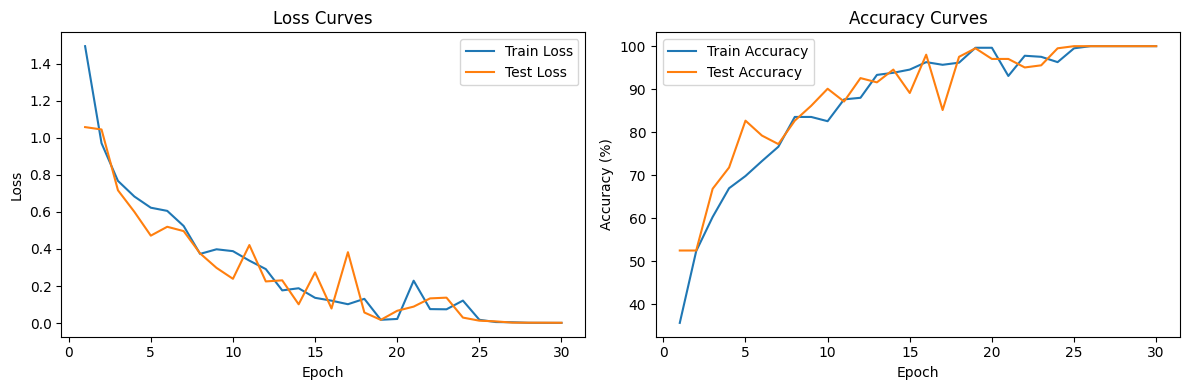

In [33]:
if __name__ == "__main__":

    DATA_DIR = "/content/drive/MyDrive/wheat_reduced"


    H, W = 128, 128
    C = 10
    T = 1
    K = 5
    PATCH_SIZE = 16
    N_CLASSES = None

    # Create dataset and split
    full_dataset = HyperspectralDataset(DATA_DIR)
    N_CLASSES = len(np.unique(full_dataset.labels))
    print(f"Found {N_CLASSES} classes, {len(full_dataset)} samples")

    train_size = int(0.8 * len(full_dataset))
    test_size = len(full_dataset) - train_size
    train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

    # Model
    input_shape = (T, H, W, C)
    model = HyperspectralTimeSeriesModel(
        input_shape=input_shape,
        n_vegetation_indices=K,
        patch_size=PATCH_SIZE,
        n_classes=N_CLASSES,
        lstm_hidden=128,
        mlp_hidden=128,
        dropout_rate=0.3
    )

    # Train
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    model, _, _, _, _ = train_model(model, train_loader, test_loader, epochs=30, lr=1e-3, device=device)